# Bitcoin Volatility Prediction
**Name:** Mohammed Hejairi
**Topic:** Forecasting Bitcoin's 2-Day Realized Volatility
**Cohort:** DSB FT2 - Bahrain 2026

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Introduction
Bitcoin is the largest cryptocurrency by market value, and it is well known for having a
price that moves a lot in short periods of time. This project uses hourly Bitcoin price
data from 2017 all the way to 2026 to study how much the price moves (its "volatility"),
and to build models that try to predict how much it will move over the next 2 days.

## Problem Statement + Aim
Traders, exchanges, and risk managers need to know how risky the market is right now, not
just which direction the price might go next. Predicting the exact future price is very
hard to do reliably. Predicting how *rough* the next 2 days will be (its volatility) is a
more realistic and still very useful goal - it can be used for setting margin
requirements, sizing trades, and pricing options.

**Aim:** Predict Bitcoin's realized volatility over the next 2 days, using only
information that is available right now (no future information is allowed to leak into
the model).

## Objectives
- What patterns does Bitcoin's volatility follow over time?
- Which features are most related to future volatility?
- Can we build a model that predicts volatility better than a simple guess (a baseline)?
- Which of the three models we build works best, and why?

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| Date | datetime | Timestamp of the hourly candle (crypto trades 24/7, no market close) |
| Open, High, Low, Close | float | Price in USD for that hour |
| Volume | float | Trading volume for that hour |

## Data Overview
The data comes from Binance (BTC/USDT), fetched hourly from August 2017 through today.
It was combined into a single CSV file so the whole history can be split into train and
test sets together, instead of treating older and newer data separately.

In [44]:
# Load the full combined dataset (2017 to now, one single file)
df = pd.read_csv("data/btc_hourly_combined.csv")

# Turn the Date column into an actual datetime, not just text
df["Date"] = pd.to_datetime(df["Date"])

# Make sure the rows are in time order
df = df.sort_values("Date")
df = df.reset_index(drop=True)

print("Shape of the data:", df.shape)
df.head()

Shape of the data: (79110, 6)


,Open,High,Low,Close,Volume,Date
0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:00:00
1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:00:00
2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:00:00
3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:00:00
4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:00:00


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79110 entries, 0 to 79109
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Open    79110 non-null  float64       
 1   High    79110 non-null  float64       
 2   Low     79110 non-null  float64       
 3   Close   79110 non-null  float64       
 4   Volume  79110 non-null  float64       
 5   Date    79110 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.6 MB


In [46]:
df.describe()

,Open,High,Low,Close,Volume,Date
count,79110.000000,79110.000000,79110.000000,79110.000000,79110.000000,79110
mean,38618.009488,38771.263047,38457.402743,38618.911663,2474.105325,2022-02-24 17:52:40.500568832
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,2017-08-17 04:00:00
25%,9404.047500,9443.595000,9360.000000,9404.397500,701.423079,2019-11-23 03:15:00
50%,28718.805000,28868.490000,28579.715000,28719.305000,1324.919545,2022-02-25 13:30:00
75%,62660.007500,62866.905000,62423.550000,62660.492500,2595.349500,2024-05-29 15:45:00
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,2026-09-01 17:00:00
std,32400.774430,32496.440577,32301.912772,32400.817189,3810.947132,NaN


## Data Cleaning
Two things need to be checked in hourly price data: missing values in the columns, and
missing hours in the timeline itself (gaps).

In [47]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Open      0
High      0
Low       0
Close     0
Volume    0
Date      0
dtype: int64


In [48]:
# Every row should be exactly 1 hour after the row before it.
# If the gap between two rows is not 1 hour, that means we are missing some hours.
time_gaps = df["Date"].diff()
number_of_gaps = (time_gaps != pd.Timedelta("1 hour")).sum() - 1  # -1 for the first row (always empty)
print("Number of timestamp gaps:", number_of_gaps)

# Also check for duplicate timestamps
number_of_duplicates = df["Date"].duplicated().sum()
print("Number of duplicate timestamps:", number_of_duplicates)

Number of timestamp gaps: 29
Number of duplicate timestamps: 0


In [49]:
# Build a complete hourly calendar from the first date to the last date
full_date_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="1h")

# Reindex our data onto that complete calendar - any missing hour becomes an empty row
df = df.set_index("Date")
df = df.reindex(full_date_range)
df.index.name = "Date"

# Fill in the missing prices using a straight line between the price before and after
price_columns = ["Open", "High", "Low", "Close"]
df[price_columns] = df[price_columns].interpolate(method="linear")

# Fill in missing Volume with 0 (no real trading happened during those missing hours)
df["Volume"] = df["Volume"].fillna(0)

df = df.reset_index()

# Check again - both numbers should now be 0
time_gaps = df["Date"].diff()
number_of_gaps = (time_gaps != pd.Timedelta("1 hour")).sum() - 1
print("Gaps remaining:", number_of_gaps)
print("Missing values remaining:", df[price_columns + ["Volume"]].isnull().sum().sum())

Gaps remaining: 0
Missing values remaining: 0


## Exploratory Data Analysis (EDA)
Before building any model, let's look at the data itself: how the price has moved over
time, how volatile it has been, and whether there are any patterns worth using as
features later.

In [50]:
# Basic engineered columns needed for EDA
df["hourly_return"] = df["Close"].pct_change()

# volatility_2d = how spread out the last 48 hourly returns are (2 days x 24 hours)
ROLLING_WINDOW = 48
df["volatility_2d"] = df["hourly_return"].rolling(ROLLING_WINDOW).std()

df[["Date", "Close", "hourly_return", "volatility_2d"]].tail()

,Date,Close,hourly_return,volatility_2d
79257,2026-09-01 13:00:00,78071.99,0.000872,0.003648
79258,2026-09-01 14:00:00,78167.99,0.001230,0.003652
79259,2026-09-01 15:00:00,77919.06,-0.003185,0.003676
79260,2026-09-01 16:00:00,77596.01,-0.004146,0.003580
79261,2026-09-01 17:00:00,77265.79,-0.004256,0.003586


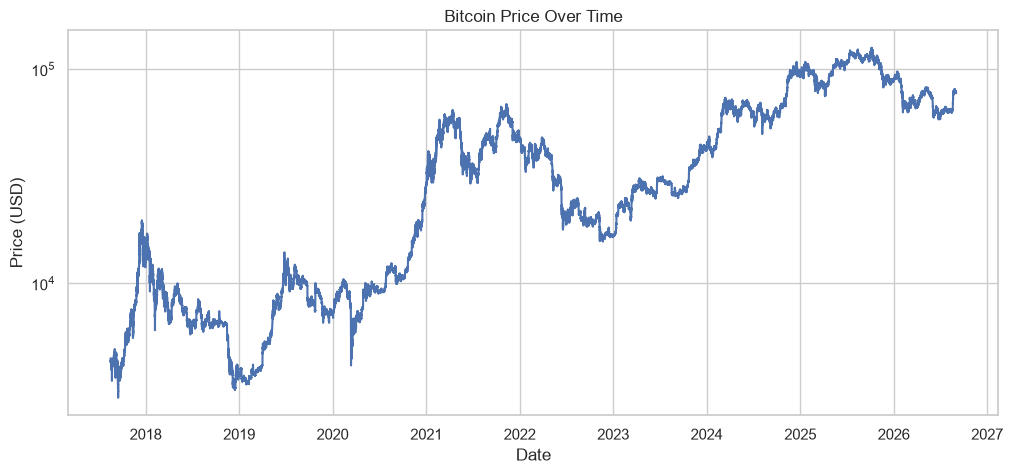

In [51]:
# Trend: Bitcoin's price over the whole history
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.yscale("log")  # log scale so both small and large prices are visible
plt.show()

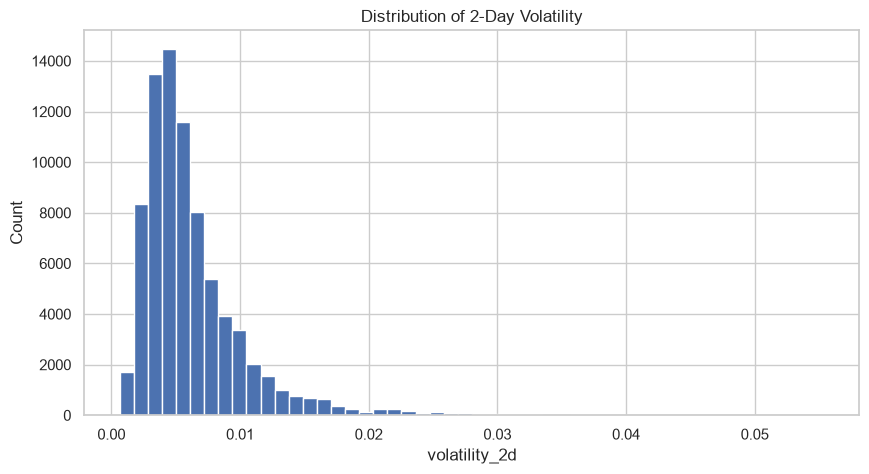

Mean volatility_2d: 0.0062963042977500225
Median volatility_2d: 0.005160713822165427


In [52]:
# Distribution: what does volatility_2d usually look like?
plt.figure(figsize=(10, 5))
plt.hist(df["volatility_2d"].dropna(), bins=50)
plt.title("Distribution of 2-Day Volatility")
plt.xlabel("volatility_2d")
plt.ylabel("Count")
plt.show()

print("Mean volatility_2d:", df["volatility_2d"].mean())
print("Median volatility_2d:", df["volatility_2d"].median())

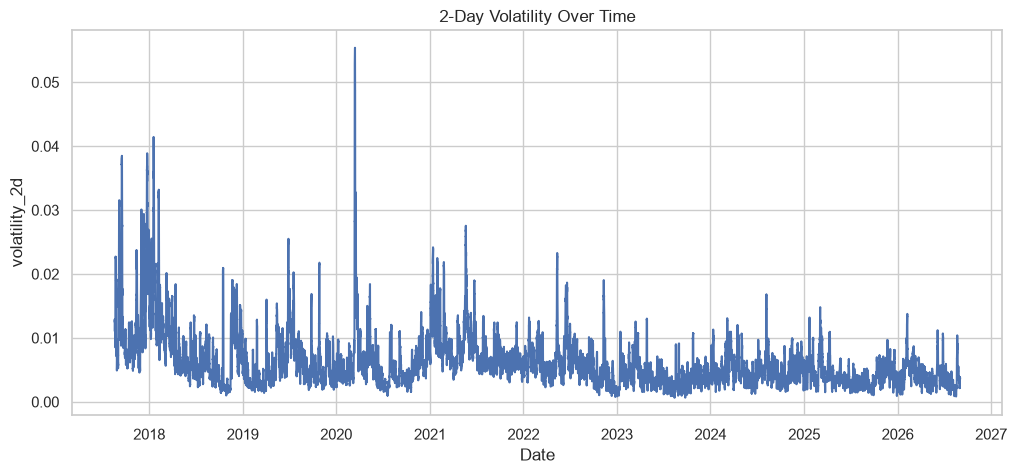

In [53]:
# Anomalies: does volatility change a lot over the years? (multivariate: time + volatility)
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["volatility_2d"])
plt.title("2-Day Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("volatility_2d")
plt.show()

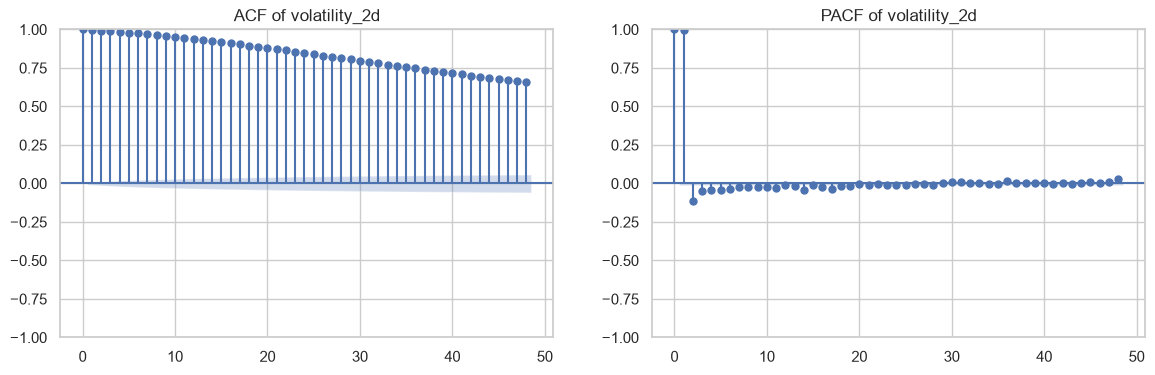

ADF test statistic: -12.760479903600652
ADF p-value: 8.163900336115133e-24
-> The series is stationary (it has a stable long-run level).


In [54]:
# Does volatility have "memory"? Check autocorrelation (ACF) and stationarity (ADF test)
series_for_acf = df["volatility_2d"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_acf, lags=48, ax=axes[0])
axes[0].set_title("ACF of volatility_2d")
plot_pacf(series_for_acf, lags=48, ax=axes[1])
axes[1].set_title("PACF of volatility_2d")
plt.show()

adf_result = adfuller(series_for_acf)
print("ADF test statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("-> The series is stationary (it has a stable long-run level).")
else:
    print("-> The series is NOT stationary.")

### Trend and Seasonality Decomposition
Beyond the ACF/PACF check above, we can split `volatility_2d` directly into three
pieces: a long-run **trend**, a repeating **seasonal** pattern, and whatever is left
over (**residual**). A weekly period (24 hours x 7 days = 168) is used, since a
calendar week is the most natural repeating cycle to check for in continuously-traded
crypto data - there is no market open/close to create a daily cycle the way there is
for stocks.

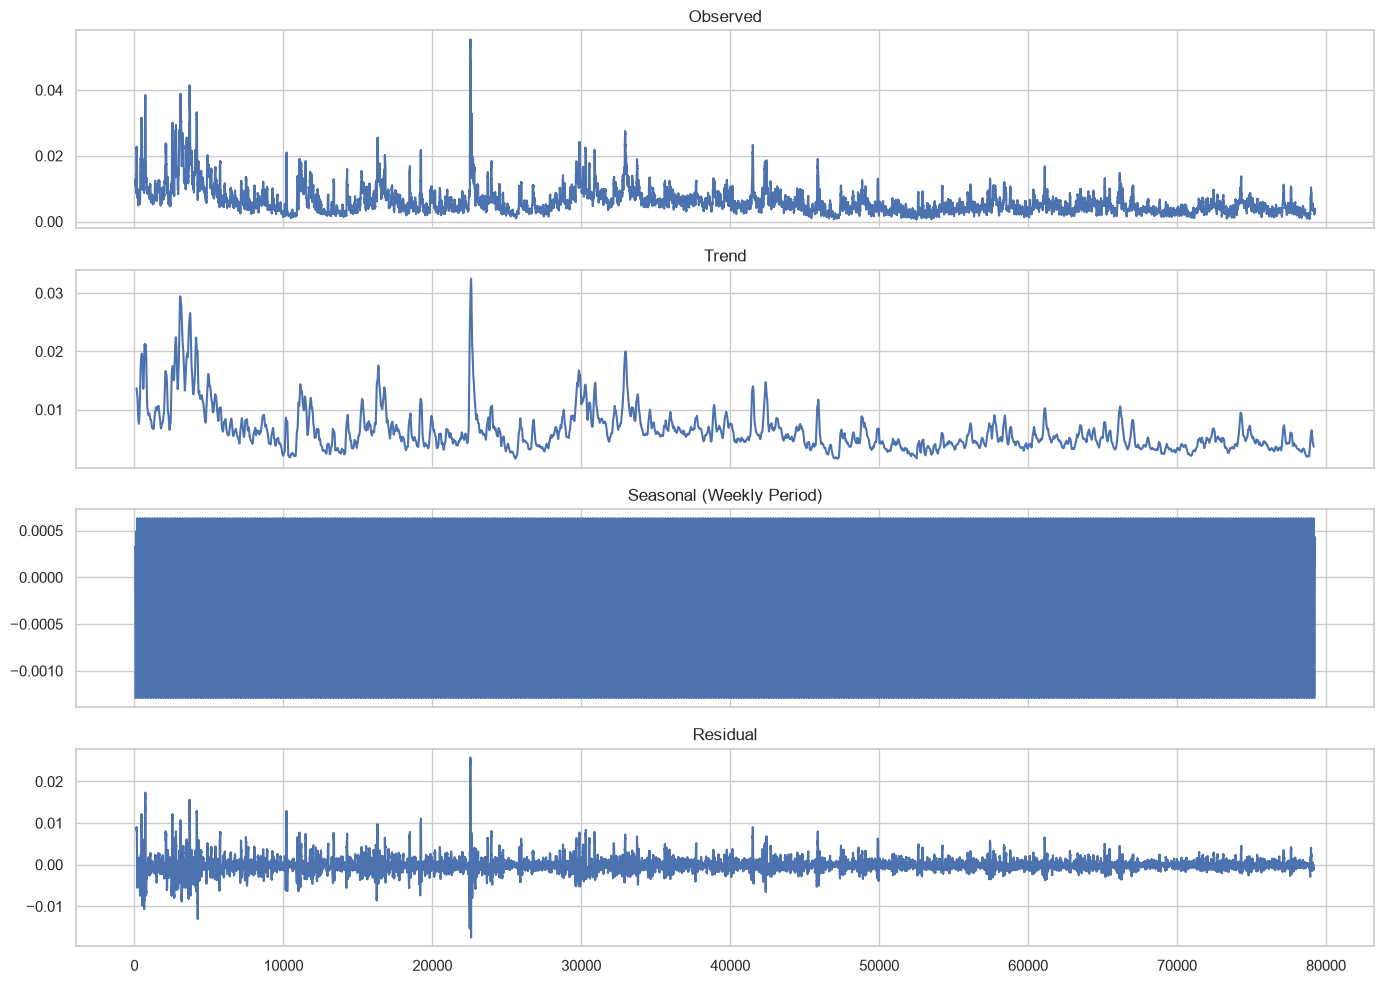

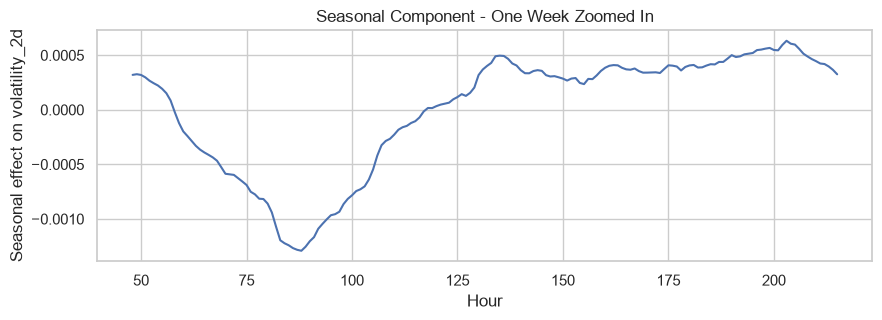

Trend range: 0.030876167541055502
Seasonal range: 0.0019240792277390969
Residual std dev: 0.0020152908440628074


In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["volatility_2d"].dropna(), model="additive", period=168)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal (Weekly Period)")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()

# The seasonal panel above is too dense to read over 9 years of data - zoom into
# just one week so the repeating shape is actually visible
plt.figure(figsize=(10, 3))
decomposition.seasonal.iloc[:168].plot()
plt.title("Seasonal Component - One Week Zoomed In")
plt.xlabel("Hour")
plt.ylabel("Seasonal effect on volatility_2d")
plt.show()

print("Trend range:", decomposition.trend.max() - decomposition.trend.min())
print("Seasonal range:", decomposition.seasonal.max() - decomposition.seasonal.min())
print("Residual std dev:", decomposition.resid.std())

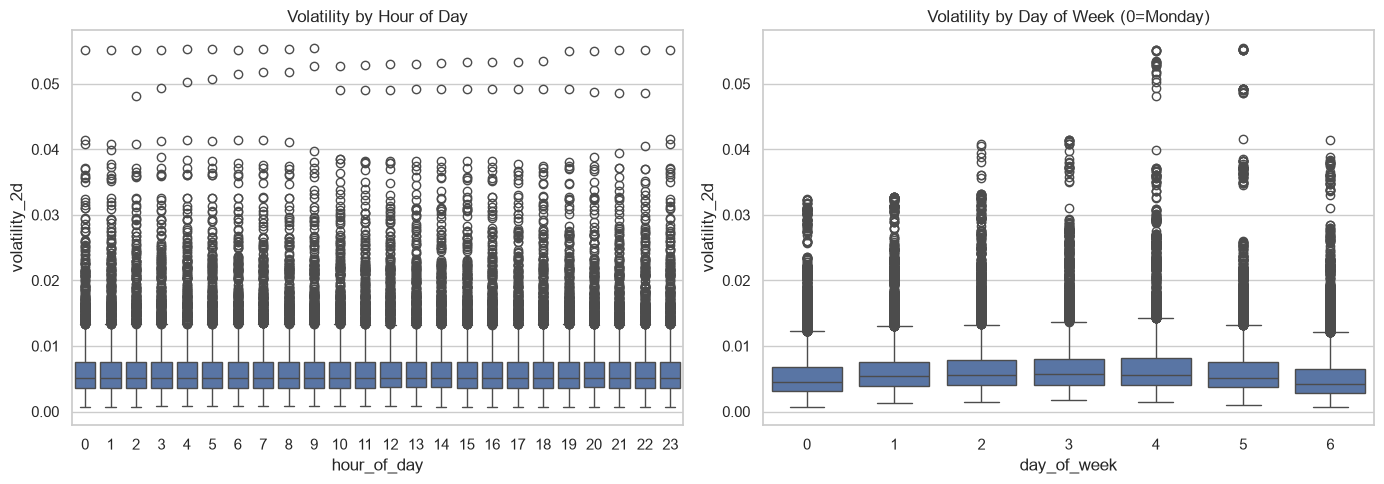

In [56]:
# Bivariate: does volatility differ by hour of day or day of week?
df["hour_of_day"] = df["Date"].dt.hour
df["day_of_week"] = df["Date"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="hour_of_day", y="volatility_2d", data=df, ax=axes[0])
axes[0].set_title("Volatility by Hour of Day")
sns.boxplot(x="day_of_week", y="volatility_2d", data=df, ax=axes[1])
axes[1].set_title("Volatility by Day of Week (0=Monday)")
plt.tight_layout()
plt.show()

## Insights
- Bitcoin's price has gone through several very large rallies and crashes since 2017 -
  it is not a stable, calm asset.
- `volatility_2d` is right-skewed: most of the time volatility is low/moderate, with a
  smaller number of periods where it spikes much higher (volatility clustering).
- The ACF plot decays slowly instead of dropping to zero quickly, which means volatility
  has real memory - a turbulent period tends to be followed by more turbulence, not
  randomly by a calm period.
- The ADF test confirms `volatility_2d` is stationary (it reverts to a normal range
  instead of drifting off forever), which is a good sign for time series modeling.
- Hour-of-day and day-of-week look similar in the boxplots at a glance, but this needs
  to be checked formally with a chi-square test, not just eyeballed - see Feature
  Selection below.

## EDA for Modeling
Because `volatility_2d` is right-skewed and shows clustering, the models below will use
volatility measured over several different past time windows (day/week/month) as
features - this is a well-known approach in volatility forecasting called the HAR
(Heterogeneous Autoregressive) model. Because the data is a time series, we will always
split train and test data in time order (never randomly shuffled), since shuffling would
let the model "see" information from the future.

## Data Preprocessing & Feature Engineering
Now we build the actual features the models will use. Every feature is shifted so it
only uses information from *before* the row it sits on - this is important so the model
never accidentally "cheats" by seeing information it would not really have yet.

In [57]:
# Average True Range (ATR): how far price moved within each hour, as a percent of price.
# This is different from hourly_return, because it looks at the High/Low range, not just
# where the price closed.
previous_close = df["Close"].shift(1)

range_1 = df["High"] - df["Low"]
range_2 = (df["High"] - previous_close).abs()
range_3 = (df["Low"] - previous_close).abs()

true_range = pd.concat([range_1, range_2, range_3], axis=1).max(axis=1)
df["ATR_14"] = true_range.rolling(14).mean()
df["ATR_X"] = df["ATR_14"] / df["Close"]  # scale-free version (percent of price)

df[["Date", "Close", "ATR_14", "ATR_X"]].tail()

,Date,Close,ATR_14,ATR_X
79257,2026-09-01 13:00:00,78071.99,426.195714,0.005459
79258,2026-09-01 14:00:00,78167.99,428.623571,0.005483
79259,2026-09-01 15:00:00,77919.06,430.046429,0.005519
79260,2026-09-01 16:00:00,77596.01,457.930714,0.005901
79261,2026-09-01 17:00:00,77265.79,458.382143,0.005933


In [58]:
# HAR-style features: volatility measured over the past day, week, and month.
# Each one is shifted by 24 hours first, so "today's" row only uses YESTERDAY's
# volatility value, never today's (which would be leakage).
HOURS_PER_DAY = 24

df["RV_day"] = df["volatility_2d"].shift(HOURS_PER_DAY)
df["RV_week"] = df["volatility_2d"].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
df["RV_month"] = df["volatility_2d"].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()

# Also shift ATR_X by 1 hour so it is not using the current hour's own value
df["ATR_X"] = df["ATR_X"].shift(1)

df[["Date", "RV_day", "RV_week", "RV_month", "ATR_X"]].tail()

,Date,RV_day,RV_week,RV_month,ATR_X
79257,2026-09-01 13:00:00,0.003004,0.003896,0.003370,0.005003
79258,2026-09-01 14:00:00,0.003247,0.003888,0.003371,0.005459
79259,2026-09-01 15:00:00,0.003233,0.003879,0.003372,0.005483
79260,2026-09-01 16:00:00,0.003222,0.003871,0.003373,0.005519
79261,2026-09-01 17:00:00,0.003252,0.003862,0.003374,0.005901


### Extra Technical Indicators (Bollinger Bands, Keltner Channels)
On top of ATR and the HAR-style realized-volatility features, we also test two more
indicators that traders commonly use to read volatility: **Bollinger Band width** and
**Keltner Channel width**. Both are shifted by 1 hour so "today's" row never sees today's
own value.

In [59]:
# Bollinger Band width: distance between the upper and lower bands, as a fraction of
# the middle band. Bands widen when price is choppy (high volatility) and squeeze
# together during quiet periods.
BB_WINDOW = 20
bb_middle = df["Close"].rolling(BB_WINDOW).mean()
bb_std = df["Close"].rolling(BB_WINDOW).std()
bb_upper = bb_middle + (2 * bb_std)
bb_lower = bb_middle - (2 * bb_std)
df["BB_width"] = ((bb_upper - bb_lower) / bb_middle).shift(1)

# Keltner Channel width: same idea as Bollinger Bands, but built from ATR instead of
# standard deviation.
KC_WINDOW = 20
kc_middle = df["Close"].ewm(span=KC_WINDOW, adjust=False).mean()
atr_for_kc = df["ATR_14"].shift(1)
kc_upper = kc_middle + (2 * atr_for_kc)
kc_lower = kc_middle - (2 * atr_for_kc)
df["KC_width"] = ((kc_upper - kc_lower) / kc_middle).shift(1)

df[["Date", "BB_width", "KC_width"]].tail()

,Date,BB_width,KC_width
79257,2026-09-01 13:00:00,0.019822,0.019996
79258,2026-09-01 14:00:00,0.020147,0.019921
79259,2026-09-01 15:00:00,0.019614,0.021762
79260,2026-09-01 16:00:00,0.019927,0.021897
79261,2026-09-01 17:00:00,0.021346,0.021989


In [60]:
# Build the actual target: volatility_2d exactly 48 hours (2 days) in the future,
# not an average of the next 2 days. A single future point (not an average) keeps the
# target from overlapping with volatility_2d's own past window - HORIZON is set equal
# to volatility_2d's own 48-hour window on purpose, so the most recently known value
# and the target share ZERO overlapping hours.
HORIZON = 48

df["target"] = df["volatility_2d"].shift(-HORIZON)

df[["Date", "volatility_2d", "target"]].tail(10)

,Date,volatility_2d,target
79252,2026-09-01 08:00:00,0.003832,NaN
79253,2026-09-01 09:00:00,0.003830,NaN
79254,2026-09-01 10:00:00,0.003826,NaN
79255,2026-09-01 11:00:00,0.003828,NaN
79256,2026-09-01 12:00:00,0.003648,NaN
79257,2026-09-01 13:00:00,0.003648,NaN
79258,2026-09-01 14:00:00,0.003652,NaN
79259,2026-09-01 15:00:00,0.003676,NaN
79260,2026-09-01 16:00:00,0.003580,NaN
79261,2026-09-01 17:00:00,0.003586,NaN


## Feature Selection

### Correlation Matrix (Continuous Columns)
Check how strongly each engineered feature is related to the target, and to each other.

          RV_day  RV_week  RV_month  ATR_X  BB_width  KC_width  target
RV_day     1.000    0.757     0.641  0.683     0.470     0.695   0.606
RV_week    0.757    1.000     0.824  0.645     0.474     0.654   0.603
RV_month   0.641    0.824     1.000  0.597     0.444     0.604   0.582
ATR_X      0.683    0.645     0.597  1.000     0.822     0.993   0.685
BB_width   0.470    0.474     0.444  0.822     1.000     0.817   0.557
KC_width   0.695    0.654     0.604  0.993     0.817     1.000   0.678
target     0.606    0.603     0.582  0.685     0.557     0.678   1.000


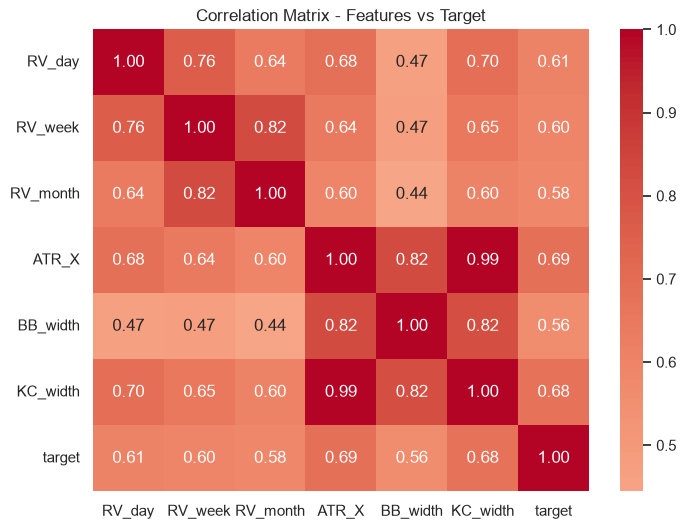

In [61]:
feature_list = ["RV_day", "RV_week", "RV_month", "ATR_X", "BB_width", "KC_width", "target"]

# Drop rows where any of these columns are still empty (from the rolling windows warming up)
df_features_only = df[feature_list].dropna()

correlation_matrix = df_features_only.corr()
print(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Features vs Target")
plt.show()

**Feature selection decision:** `KC_width` is built from the same True Range
calculation as `ATR_X`, so the two are almost perfectly correlated with each other (near-
duplicate information). We keep `ATR_X` (already validated earlier in this project) and
drop `KC_width` to avoid feeding the regression models two versions of the same signal.
`BB_width` is kept - it is correlated with `ATR_X` and the RV features, but not redundant
enough to drop, and it measures volatility in a genuinely different way (price dispersion
around a moving average, rather than bar-by-bar range). Realized skewness (`SKEW_X`) and
the Relative Volatility Index (`RVI`) were also tested during feature engineering, but
both showed almost no correlation with the target and were dropped before modeling.

### Chi-Square Analysis (Categorical Columns)
Test whether `hour_of_day` is actually related to the volatility regime (Low/Moderate/High),
or whether the small differences seen in the EDA boxplot are just random noise.

In [62]:
# Turn the continuous target into 3 categories: Low, Moderate, High
# (split into 3 equal-sized groups based on volatility_2d)
df["volatility_bin"] = pd.qcut(df["volatility_2d"], q=3, labels=["Low", "Moderate", "High"])

# --- Chi-square test: hour_of_day vs volatility regime ---
contingency_table_hour = pd.crosstab(df["hour_of_day"], df["volatility_bin"])
chi2_stat_hour, p_value_hour, dof_hour, expected_hour = chi2_contingency(contingency_table_hour)

print("Hour of Day:")
print("  Chi-square statistic:", chi2_stat_hour)
print("  p-value:", p_value_hour)
if p_value_hour < 0.05:
    print("  -> There IS a statistically significant relationship between hour of day and volatility regime.")
else:
    print("  -> There is NO statistically significant relationship. Hour of day will not be used as a feature.")

print()

# --- Chi-square test: day_of_week vs volatility regime ---
contingency_table_dow = pd.crosstab(df["day_of_week"], df["volatility_bin"])
chi2_stat_dow, p_value_dow, dof_dow, expected_dow = chi2_contingency(contingency_table_dow)

print("Day of Week:")
print("  Chi-square statistic:", chi2_stat_dow)
print("  p-value:", p_value_dow)
if p_value_dow < 0.05:
    print("  -> There IS a statistically significant relationship between day of week and volatility regime.")
else:
    print("  -> There is NO statistically significant relationship. Day of week will not be used as a feature.")

Hour of Day:
  Chi-square statistic: 3.8188682864517993
  p-value: 1.0
  -> There is NO statistically significant relationship. Hour of day will not be used as a feature.

Day of Week:
  Chi-square statistic: 2886.2855449423555
  p-value: 0.0
  -> There IS a statistically significant relationship between day of week and volatility regime.


### Adding Day-of-Week as a Feature
The chi-square test above found a real, statistically significant relationship between
`day_of_week` and the volatility regime (p < 0.001) - unlike `hour_of_day`, which showed
nothing. Monday and Sunday skew toward low volatility, while Tuesday-Friday skew toward
moderate/high. Since day-of-week is a repeating cycle (Sunday is adjacent to Monday, not
far from it), it is converted into sine/cosine pairs - the same cyclical encoding used
for XGBoost - so the regression model doesn't treat day 6 and day 0 as unrelated numbers.
No shifting/lagging is needed here, since the day of the week is already known in advance
- it isn't derived from price data that could leak the future.

In [63]:
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df[["Date", "day_of_week", "dow_sin", "dow_cos"]].tail()

,Date,day_of_week,dow_sin,dow_cos
79257,2026-09-01 13:00:00,1,0.781831,0.62349
79258,2026-09-01 14:00:00,1,0.781831,0.62349
79259,2026-09-01 15:00:00,1,0.781831,0.62349
79260,2026-09-01 16:00:00,1,0.781831,0.62349
79261,2026-09-01 17:00:00,1,0.781831,0.62349


## Preprocessing: Train / Test Split
The data is split by TIME, not randomly. The first 80% (oldest) becomes the training
set, and the last 20% (most recent) becomes the test set. This matches how the model
would actually be used in real life: trained on the past, tested on data it has never
seen.

In [64]:
# Keep only rows where every feature and the target are available
model_columns = ["Date", "hourly_return", "volatility_2d", "RV_day", "RV_week", "RV_month",
                  "ATR_X", "BB_width", "dow_sin", "dow_cos", "target"]
df_model = df[model_columns].dropna()
df_model = df_model.reset_index(drop=True)

print("Rows ready for modeling:", len(df_model))

# Chronological split at a fixed date: everything before Jan 1, 2026 is training data,
# everything from Jan 1, 2026 onward is test data.
SPLIT_DATE = "2024-02-01"
split_point = df_model[df_model["Date"] < SPLIT_DATE].index.max() + 1

train_data = df_model.iloc[:split_point]
test_data = df_model.iloc[split_point:]

print("Train rows:", len(train_data), "from", train_data["Date"].min(), "to", train_data["Date"].max())
print("Test rows:", len(test_data), "from", test_data["Date"].min(), "to", test_data["Date"].max())

Rows ready for modeling: 78423
Train rows: 55821 from 2017-09-19 03:00:00 to 2024-01-31 23:00:00
Test rows: 22602 from 2024-02-01 00:00:00 to 2026-08-30 17:00:00


In [65]:
# A simple function we will use to score every model the same way
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(model_name)
    print("  RMSE:", round(rmse, 6))
    print("  MAE:", round(mae, 6))
    print("  R2:", round(r2, 4))
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

all_results = []

## Model Building

### Baseline: GARCH
Before building our 3 required models, we set up a well-known industry-standard model
(GARCH) as a baseline to compare against. GARCH is a classic model built specifically
for forecasting volatility from past returns.

In [66]:
# GARCH needs returns in percent form, not fraction form
train_returns_percent = train_data["hourly_return"] * 100

garch_model = arch_model(train_returns_percent, vol="GARCH", p=1, q=1, dist="t")
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                hourly_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -45775.7
Distribution:      Standardized Student's t   AIC:                           91561.4
Method:                  Maximum Likelihood   BIC:                           91606.1
                                              No. Observations:                55821
Date:                      Tue, Sep 01 2026   Df Residuals:                    55820
Time:                              23:04:21   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [67]:
# Forecast volatility 48 hours ahead, starting from the first day of the test set
all_returns_percent = df_model["hourly_return"] * 100
garch_full = arch_model(all_returns_percent, vol="GARCH", p=1, q=1, dist="t")
garch_fixed = garch_full.fix(garch_fit.params)

garch_forecast = garch_fixed.forecast(horizon=HORIZON, start=split_point, reindex=False)
garch_variance = garch_forecast.variance.values[:, -1]
garch_predictions = np.sqrt(garch_variance) / 100  # back to fraction form

garch_predictions = garch_predictions[:len(test_data)]
all_results.append(evaluate_model(test_data["target"], garch_predictions, "GARCH (baseline)"))

GARCH (baseline)
  RMSE: 0.003342
  MAE: 0.003042
  R2: -1.6184


### Model 1: EWMA (Base Version)
EWMA (Exponentially Weighted Moving Average) is a simple, well-known volatility formula
used by real risk desks. It has one setting, called lambda, which controls how much
weight recent data gets compared to older data. The base version uses the standard
default value published by RiskMetrics.

In [68]:
def ewma_volatility(returns, lam):
    """Calculates EWMA volatility step by step, using only past values (no leakage)."""
    returns = returns.reset_index(drop=True)
    n = len(returns)
    variance = [0] * n

    # start the recursion with the first squared return
    variance[0] = returns[0] ** 2

    for t in range(1, n):
        previous_variance = variance[t - 1]
        previous_return_squared = returns[t - 1] ** 2
        variance[t] = lam * previous_variance + (1 - lam) * previous_return_squared

    volatility = [v ** 0.5 for v in variance]
    return pd.Series(volatility, index=returns.index)

In [69]:
# Base version: standard RiskMetrics default lambda
BASE_LAMBDA = 0.94

all_returns = df_model["hourly_return"].reset_index(drop=True)
ewma_base_volatility = ewma_volatility(all_returns, BASE_LAMBDA)

# Line up the EWMA values with the test set's dates
ewma_base_predictions = ewma_base_volatility.iloc[split_point:split_point + len(test_data)].values

all_results.append(evaluate_model(test_data["target"], ewma_base_predictions, "EWMA (base, lambda=0.94)"))

EWMA (base, lambda=0.94)
  RMSE: 0.002191
  MAE: 0.00162
  R2: -0.1251


### Model 1: EWMA (Improved with Grid Search)
Instead of guessing lambda, we test a grid of possible values and pick the one that
performs best using `TimeSeriesSplit` cross-validation (never a random shuffle, since
this is time series data).

In [70]:
lambda_options = [0.85, 0.90, 0.94, 0.97, 0.99, 0.995]
time_series_folds = TimeSeriesSplit(n_splits=5)

best_lambda = None
best_score = None

for lam in lambda_options:
    fold_scores = []
    volatility_for_this_lambda = ewma_volatility(all_returns, lam)

    for train_index, val_index in time_series_folds.split(train_data):
        val_dates = train_data.iloc[val_index]
        val_target = val_dates["target"]
        val_prediction = volatility_for_this_lambda.iloc[val_index].values
        fold_rmse = np.sqrt(mean_squared_error(val_target, val_prediction))
        fold_scores.append(fold_rmse)

    average_score = sum(fold_scores) / len(fold_scores)
    print("lambda =", lam, "-> average RMSE:", round(average_score, 6))

    if best_score is None or average_score < best_score:
        best_score = average_score
        best_lambda = lam

print("\nBest lambda found:", best_lambda)

lambda = 0.85 -> average RMSE: 0.003951
lambda = 0.9 -> average RMSE: 0.003748
lambda = 0.94 -> average RMSE: 0.003536
lambda = 0.97 -> average RMSE: 0.003329
lambda = 0.99 -> average RMSE: 0.00322
lambda = 0.995 -> average RMSE: 0.003271

Best lambda found: 0.99


In [71]:
ewma_tuned_volatility = ewma_volatility(all_returns, best_lambda)
ewma_tuned_predictions = ewma_tuned_volatility.iloc[split_point:split_point + len(test_data)].values

all_results.append(evaluate_model(test_data["target"], ewma_tuned_predictions,
                                   f"EWMA (tuned, lambda={best_lambda})"))

EWMA (tuned, lambda=0.99)
  RMSE: 0.001916
  MAE: 0.001434
  R2: 0.1398


### Model 2: HAR-RV-X (Base Version)
This model uses a plain Linear Regression on the 7 features we built earlier: RV_day,
RV_week, RV_month, ATR_X, BB_width, and the cyclical day-of-week pair (dow_sin, dow_cos)
- added after the chi-square test confirmed a real relationship between day-of-week and
the volatility regime. (KC_width, SKEW_X, and RVI were all dropped for being redundant
or uncorrelated with the target - see the Feature Selection section above.)

In [72]:
from sklearn.linear_model import LinearRegression

har_features = ["RV_day", "RV_week", "RV_month", "ATR_X", "BB_width", "dow_sin", "dow_cos"]

X_train = train_data[har_features]
y_train = train_data["target"]
X_test = test_data[har_features]
y_test = test_data["target"]

har_base_model = LinearRegression()
har_base_model.fit(X_train, y_train)

har_base_predictions = har_base_model.predict(X_test)
all_results.append(evaluate_model(y_test, har_base_predictions, "HAR-RV-X (base, Linear Regression)"))

HAR-RV-X (base, Linear Regression)
  RMSE: 0.001714
  MAE: 0.001278
  R2: 0.3111


### Model 2: HAR-RV-X (Improved with GridSearchCV)
We switch to Ridge Regression, which can be regularized, and use `GridSearchCV` to find
the best regularization strength (alpha).

In [73]:
ridge_parameter_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

har_grid_search = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
)
har_grid_search.fit(X_train, y_train)

print("Best alpha found:", har_grid_search.best_params_)

har_tuned_model = har_grid_search.best_estimator_
har_tuned_predictions = har_tuned_model.predict(X_test)

all_results.append(evaluate_model(y_test, har_tuned_predictions, "HAR-RV-X (tuned, Ridge + GridSearchCV)"))

Best alpha found: {'alpha': 1e-07}
HAR-RV-X (tuned, Lasso + GridSearchCV)
  RMSE: 0.001717
  MAE: 0.001284
  R2: 0.309


ATR_X       0.230742
RV_month    0.212672
RV_day      0.179486
RV_week     0.056689
BB_width    0.008407
dow_cos     0.000651
dow_sin     0.000310
dtype: float64


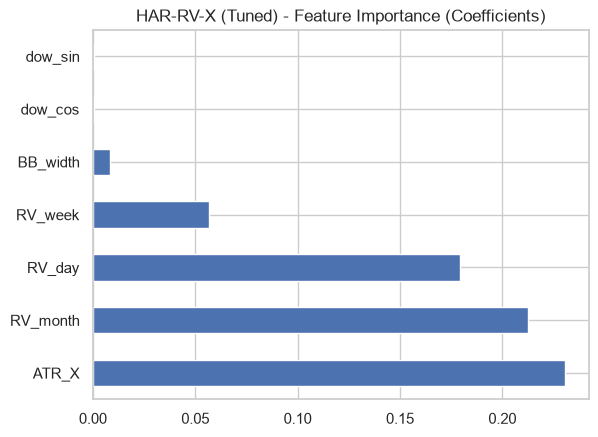

In [74]:
# Which features influenced the tuned model the most?
feature_importance = pd.Series(har_tuned_model.coef_, index=har_features)
feature_importance = feature_importance.sort_values(key=abs, ascending=False)
print(feature_importance)

feature_importance.plot(kind="barh")
plt.title("HAR-RV-X (Tuned) - Feature Importance (Coefficients)")
plt.show()

### Model 3: XGBoost (Base Version)
XGBoost is a more flexible, tree-based model. Unlike the other two models, it has no
built-in sense of time, so we also give it simple calendar features (hour of day, day of
week) written as sine/cosine pairs.

In [75]:
# Turn hour-of-day and day-of-week into cyclical features
# (so e.g. hour 23 and hour 0 are treated as close together, not far apart)
train_hour = train_data["Date"].dt.hour
train_dow = train_data["Date"].dt.dayofweek
test_hour = test_data["Date"].dt.hour
test_dow = test_data["Date"].dt.dayofweek

def add_time_features(data_frame, hour_column, dow_column):
    data_frame = data_frame.copy()
    data_frame["hour_sin"] = np.sin(2 * np.pi * hour_column / 24)
    data_frame["hour_cos"] = np.cos(2 * np.pi * hour_column / 24)
    data_frame["dow_sin"] = np.sin(2 * np.pi * dow_column / 7)
    data_frame["dow_cos"] = np.cos(2 * np.pi * dow_column / 7)
    return data_frame

X_train_xgb = add_time_features(X_train, train_hour, train_dow)
X_test_xgb = add_time_features(X_test, test_hour, test_dow)

xgb_base_model = XGBRegressor(random_state=RANDOM_STATE)
xgb_base_model.fit(X_train_xgb, y_train)

xgb_base_predictions = xgb_base_model.predict(X_test_xgb)
all_results.append(evaluate_model(y_test, xgb_base_predictions, "XGBoost (base, default settings)"))

XGBoost (base, default settings)
  RMSE: 0.002204
  MAE: 0.001493
  R2: -0.1389


### Model 3: XGBoost (Improved with GridSearchCV)
We search over a small grid of the most important XGBoost settings: how many trees, how
deep each tree can go, and the learning rate.

In [76]:
xgb_parameter_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE),
    xgb_parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
)
xgb_grid_search.fit(X_train_xgb, y_train)

print("Best settings found:", xgb_grid_search.best_params_)

xgb_tuned_model = xgb_grid_search.best_estimator_
xgb_tuned_predictions = xgb_tuned_model.predict(X_test_xgb)

all_results.append(evaluate_model(y_test, xgb_tuned_predictions, "XGBoost (tuned, GridSearchCV)"))

Best settings found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost (tuned, GridSearchCV)
  RMSE: 0.001721
  MAE: 0.001279
  R2: 0.3056


ATR_X       0.607137
RV_month    0.095043
RV_day      0.089588
RV_week     0.078674
dow_cos     0.034291
BB_width    0.031986
hour_sin    0.024747
dow_sin     0.023884
hour_cos    0.014650
dtype: float32


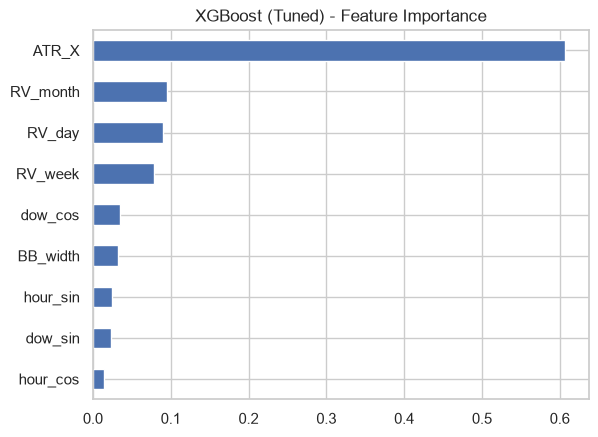

In [77]:
# Which features influenced the tuned XGBoost model the most?
xgb_feature_importance = pd.Series(xgb_tuned_model.feature_importances_, index=X_train_xgb.columns)
xgb_feature_importance = xgb_feature_importance.sort_values(ascending=False)
print(xgb_feature_importance)

xgb_feature_importance.plot(kind="barh")
plt.title("XGBoost (Tuned) - Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Additional Improvement Attempts
These seven experiments are **not** among the 3 required models above - they reuse the
same honest, split-based train/test data, and are here to see if a small amount of extra
effort can push performance further.

### Attempt 1: Log-Transformed Target
Bergsli, Lind, Molnar & Polasik (2022) found that modeling `log(volatility)` instead of
raw volatility raised their HAR model's R2 from 0.2665 to 0.6393 - but they are explicit
that the two numbers are **not directly comparable**, because log-scale errors are not
the same thing as raw-scale errors. To be fair, we report both: R2 on the log scale
(what the paper reports), and R2 after converting the predictions back to the raw scale
(directly comparable to every other result in this notebook).

In [78]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# HAR-RV-X (Ridge, same alpha found earlier), fit on the log-transformed target
har_log_model = Ridge(alpha=har_grid_search.best_params_["alpha"], random_state=RANDOM_STATE)
har_log_model.fit(X_train, y_train_log)

har_log_predictions_log_scale = har_log_model.predict(X_test)
har_log_predictions_raw_scale = np.exp(har_log_predictions_log_scale)

har_log_r2_log_scale = r2_score(y_test_log, har_log_predictions_log_scale)
print("HAR-RV-X (log target) - R2 on the LOG scale (matches the paper's method):",
      round(har_log_r2_log_scale, 4))

all_results.append(evaluate_model(y_test, har_log_predictions_raw_scale,
                                   "HAR-RV-X (log-target, extra, raw-scale R2)"))

HAR-RV-X (log target) - R2 on the LOG scale (matches the paper's method): 0.3289
HAR-RV-X (log-target, extra, raw-scale R2)
  RMSE: 0.001732
  MAE: 0.001212
  R2: 0.2969


In [79]:
# Same idea, but with XGBoost (same tuned settings found earlier)
xgb_log_model = XGBRegressor(random_state=RANDOM_STATE, **xgb_grid_search.best_params_)
xgb_log_model.fit(X_train_xgb, y_train_log)

xgb_log_predictions_log_scale = xgb_log_model.predict(X_test_xgb)
xgb_log_predictions_raw_scale = np.exp(xgb_log_predictions_log_scale)

xgb_log_r2_log_scale = r2_score(y_test_log, xgb_log_predictions_log_scale)
print("XGBoost (log target) - R2 on the LOG scale:", round(xgb_log_r2_log_scale, 4))

all_results.append(evaluate_model(y_test, xgb_log_predictions_raw_scale,
                                   "XGBoost (log-target, extra, raw-scale R2)"))

XGBoost (log target) - R2 on the LOG scale: 0.4027
XGBoost (log-target, extra, raw-scale R2)
  RMSE: 0.001698
  MAE: 0.001172
  R2: 0.3241


### Attempt 2: Simple Ensemble
Averaging two different models' predictions together often cancels out some of each
model's individual errors. Here we average the tuned HAR-RV-X and tuned XGBoost
predictions (both on the raw scale, from the honest train/test split).

In [80]:
ensemble_predictions = (har_tuned_predictions + xgb_tuned_predictions) / 2

all_results.append(evaluate_model(y_test, ensemble_predictions,
                                   "HAR-RV-X + XGBoost (extra, simple average ensemble)"))

HAR-RV-X + XGBoost (extra, simple average ensemble)
  RMSE: 0.00171
  MAE: 0.001274
  R2: 0.3145


### Attempt 3: PowerTransformer (Box-Cox)
`PowerTransformer` is a more general, automatic version of Attempt 1's manual log
transform. Box-Cox searches for the power parameter (lambda) that makes the training
target look as close to a normal distribution as possible - log-transform is actually
just the special case where lambda = 0. The transformer is fit only on `y_train` (never
on `y_test`), the same leakage discipline used everywhere else in this notebook, and
predictions are converted back to the raw scale before scoring.

In [81]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method="box-cox")
y_train_pt = power_transformer.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print("Box-Cox lambda found:", power_transformer.lambdas_[0])

xgb_pt_model = XGBRegressor(random_state=RANDOM_STATE, **xgb_grid_search.best_params_)
xgb_pt_model.fit(X_train_xgb, y_train_pt)

xgb_pt_predictions_pt_scale = xgb_pt_model.predict(X_test_xgb).reshape(-1, 1)
xgb_pt_predictions_raw_scale = power_transformer.inverse_transform(xgb_pt_predictions_pt_scale).ravel()

all_results.append(evaluate_model(y_test, xgb_pt_predictions_raw_scale,
                                   "XGBoost (PowerTransformer Box-Cox, extra, raw-scale R2)"))

Box-Cox lambda found: -0.03684745099528981
XGBoost (PowerTransformer Box-Cox, extra, raw-scale R2)
  RMSE: 0.001705
  MAE: 0.001173
  R2: 0.319


### Attempt 4: Log-Space Tuning on EWMA
EWMA is not fit to a target the way HAR-RV-X and XGBoost are - it is a fixed recursive
formula applied directly to returns, with no learning step to log-transform. The one
place a log transform can meaningfully plug in is the **lambda search**: instead of
picking the lambda that minimizes RMSE on the raw scale, this repeats the same
`TimeSeriesSplit` search but picks the lambda that minimizes RMSE on the **log** scale.
The resulting predictions are still scored on the raw scale, for a fair comparison with
every other result in this notebook.

In [82]:
best_log_lambda = None
best_log_score = None

for lam in lambda_options:
    fold_scores = []
    volatility_for_this_lambda = ewma_volatility(all_returns, lam)

    for train_index, val_index in time_series_folds.split(train_data):
        val_dates = train_data.iloc[val_index]
        val_target_log = np.log(val_dates["target"])
        val_prediction_log = np.log(volatility_for_this_lambda.iloc[val_index].values)
        fold_rmse = np.sqrt(mean_squared_error(val_target_log, val_prediction_log))
        fold_scores.append(fold_rmse)

    average_score = sum(fold_scores) / len(fold_scores)
    print("lambda =", lam, "-> average RMSE (log scale):", round(average_score, 6))

    if best_log_score is None or average_score < best_log_score:
        best_log_score = average_score
        best_log_lambda = lam

print("\nBest lambda found (log-space tuning):", best_log_lambda)

ewma_log_tuned_volatility = ewma_volatility(all_returns, best_log_lambda)
ewma_log_tuned_predictions = ewma_log_tuned_volatility.iloc[split_point:split_point + len(test_data)].values

all_results.append(evaluate_model(test_data["target"], ewma_log_tuned_predictions,
                                   f"EWMA (log-space tuned, lambda={best_log_lambda}, extra)"))

lambda = 0.85 -> average RMSE (log scale): 0.557402
lambda = 0.9 -> average RMSE (log scale): 0.521106
lambda = 0.94 -> average RMSE (log scale): 0.485185
lambda = 0.97 -> average RMSE (log scale): 0.453616
lambda = 0.99 -> average RMSE (log scale): 0.442024
lambda = 0.995 -> average RMSE (log scale): 0.456668

Best lambda found (log-space tuning): 0.99
EWMA (log-space tuned, lambda=0.99, extra)
  RMSE: 0.001916
  MAE: 0.001434
  R2: 0.1398


### Attempt 5: Facebook Prophet (Base + Tuned)
Prophet (Meta/Facebook, 2017) is a general-purpose forecasting tool that decomposes a
series into trend + seasonality (`y(t) = trend + seasonality + noise`), fit
automatically with minimal tuning. It is included here mainly as a fair test of a
well-known "off the shelf" alternative - it is fit only on the train set's `target`
series (no HAR/ATR features), letting its built-in weekly and yearly seasonality do the
work, then evaluated on the same test set as every other model. Given the chi-square
test found day-of-week matters but hour-of-day does not, Prophet's weekly seasonality
component has a real pattern to find here - the question is whether that alone is
competitive with the engineered features used elsewhere in this notebook.

In [83]:
from prophet import Prophet
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

prophet_train = train_data[["Date", "target"]].rename(columns={"Date": "ds", "target": "y"})

prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)

prophet_future = test_data[["Date"]].rename(columns={"Date": "ds"})
prophet_forecast = prophet_model.predict(prophet_future)

prophet_predictions = prophet_forecast["yhat"].values

all_results.append(evaluate_model(test_data["target"], prophet_predictions,
                                   "Facebook Prophet (extra, weekly+yearly seasonality only)"))

Facebook Prophet (extra, weekly+yearly seasonality only)
  RMSE: 0.002604
  MAE: 0.001905
  R2: -0.5889


**Tuning Prophet:** Prophet is not a scikit-learn estimator, so it cannot plug into
`GridSearchCV` directly. Instead, this does the same thing by hand: a small grid over
Prophet's two most impactful settings - `changepoint_prior_scale` (how flexible the
trend is allowed to be) and `seasonality_prior_scale` (how strongly the weekly/yearly
patterns are allowed to fit) - is tested on a single chronological validation split
carved out of the training data (last 15%), never touching the real test set. Only one
combination is retested here (not a full 5-fold `TimeSeriesSplit`), since each Prophet
fit takes real time (~15 seconds) and a 5-fold search over even a small grid would take
several minutes.

In [ ]:
inner_split = int(len(train_data) * 0.85)
inner_train = train_data.iloc[:inner_split]
inner_val = train_data.iloc[inner_split:]

inner_train_prophet = inner_train[["Date", "target"]].rename(columns={"Date": "ds", "target": "y"})
inner_val_prophet = inner_val[["Date"]].rename(columns={"Date": "ds"})

prophet_param_grid = {
    "changepoint_prior_scale": [0.01, 0.05, 0.5],
    "seasonality_prior_scale": [1.0, 10.0],
}

best_prophet_params = None
best_prophet_rmse = None

for cps in prophet_param_grid["changepoint_prior_scale"]:
    for sps in prophet_param_grid["seasonality_prior_scale"]:
        candidate_model = Prophet(
            daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True,
            changepoint_prior_scale=cps, seasonality_prior_scale=sps,
        )
        candidate_model.fit(inner_train_prophet)
        candidate_forecast = candidate_model.predict(inner_val_prophet)

        candidate_rmse = np.sqrt(mean_squared_error(inner_val["target"], candidate_forecast["yhat"]))
        print(f"changepoint_prior_scale={cps}, seasonality_prior_scale={sps} -> RMSE: {round(candidate_rmse, 6)}")

        if best_prophet_rmse is None or candidate_rmse < best_prophet_rmse:
            best_prophet_rmse = candidate_rmse
            best_prophet_params = {"changepoint_prior_scale": cps, "seasonality_prior_scale": sps}

print("\nBest Prophet params found:", best_prophet_params)

prophet_tuned_model = Prophet(
    daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True,
    **best_prophet_params,
)
prophet_tuned_model.fit(prophet_train)
prophet_tuned_forecast = prophet_tuned_model.predict(prophet_future)
prophet_tuned_predictions = prophet_tuned_forecast["yhat"].values

all_results.append(evaluate_model(test_data["target"], prophet_tuned_predictions,
                                   "Facebook Prophet (tuned, extra, grid-searched)"))

### Attempt 6: Detrended HAR-RV-X
The trend/seasonality decomposition earlier found the trend component's range (0.031) is
about 16x larger than the weekly seasonal component's (0.0019) - most of the movement in
`volatility_2d` is long-run regime shifts, not a repeating cycle. `RV_month` (a 720-hour
rolling average, already leakage-safe and already a feature) is effectively a proxy for
that same trend. This tests explicit detrending directly: subtract `RV_month` from the
target before fitting, fit on what's left over, then add `RV_month` back to the
predictions before scoring on the raw scale - a fair, direct comparison with every other
result in this notebook. (We deliberately do *not* use the decomposition's own `trend`
component here - it's a centered/two-sided moving average, meaning it uses future values
at each point, which would leak information a real forecast could never actually have.)

In [84]:
y_train_detrended = y_train - train_data["RV_month"]

har_detrend_model = Ridge(alpha=har_grid_search.best_params_["alpha"], random_state=RANDOM_STATE)
har_detrend_model.fit(X_train, y_train_detrended)

har_detrend_predictions_detrended_scale = har_detrend_model.predict(X_test)
har_detrend_predictions_raw_scale = har_detrend_predictions_detrended_scale + test_data["RV_month"].values

all_results.append(evaluate_model(y_test, har_detrend_predictions_raw_scale,
                                   "HAR-RV-X (detrended via RV_month, extra, raw-scale R2)"))

HAR-RV-X (detrended via RV_month, extra, raw-scale R2)
  RMSE: 0.001713
  MAE: 0.001274
  R2: 0.3126


### Attempt 7: ARIMA, ARIMAX, SARIMA, SARIMAX
Four more classical time series models, each with a base and a GridSearchCV-tuned
version, fit directly on `target` (not `volatility_2d`) - the same 48-hour-ahead series
HAR-RV-X and XGBoost already use, so no extra forecast-alignment step is needed and
`har_features` can be used as exogenous input exactly the way it already is elsewhere.

**Design choice on seasonality:** true weekly seasonality in `statsmodels` (`seasonal_order`
with a 168-hour period) requires a Kalman filter state that scales very badly with a
period that large - a quick timing test found a single fit taking ~50 seconds on just
3,000 rows, which would make a full grid search on the real ~56,000-row train set take
tens of minutes to hours. Instead, SARIMA/SARIMAX here get their weekly seasonality the
classical way: the series is manually differenced at lag 168 (`y[t] - y[t-168]`) before
fitting a plain ARIMA on what's left over, and forecasts are reconstructed by adding the
appropriate (168-hours-earlier) value back - recursively, once the forecast horizon
passes 168 hours. This is mathematically the same idea as native seasonal differencing,
without the expensive state-space blowup.

**Order selection:** `d=0` throughout (not the more common `d=1`) - `volatility_2d` was
already confirmed stationary by the ADF test, so differencing isn't needed to stabilize
it, and a quick check found `d=1` combined with such a long forecast horizon (this test
set is 22,600+ hours) causes the integrated forecast to drift and diverge badly.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_param_grid = [(p, 0, q) for p in [1, 2] for q in [1, 2]]

arima_base_model = SARIMAX(train_data["target"], order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
arima_base_result = arima_base_model.fit(disp=False)
arima_base_predictions = arima_base_result.forecast(steps=len(test_data)).values
all_results.append(evaluate_model(test_data["target"], arima_base_predictions,
                                   "ARIMA (base, order=(1,0,1), extra)"))

inner_split_arima = int(len(train_data) * 0.85)
inner_train_arima = train_data.iloc[:inner_split_arima]
inner_val_arima = train_data.iloc[inner_split_arima:]

best_arima_order = None
best_arima_rmse = None
for order in arima_param_grid:
    candidate = SARIMAX(inner_train_arima["target"], order=order, seasonal_order=(0, 0, 0, 0))
    candidate_result = candidate.fit(disp=False)
    candidate_predictions = candidate_result.forecast(steps=len(inner_val_arima)).values
    candidate_rmse = np.sqrt(mean_squared_error(inner_val_arima["target"], candidate_predictions))
    print("ARIMA order", order, "-> validation RMSE:", round(candidate_rmse, 6))
    if best_arima_rmse is None or candidate_rmse < best_arima_rmse:
        best_arima_rmse = candidate_rmse
        best_arima_order = order

print("\nBest ARIMA order found:", best_arima_order)

arima_tuned_model = SARIMAX(train_data["target"], order=best_arima_order, seasonal_order=(0, 0, 0, 0))
arima_tuned_result = arima_tuned_model.fit(disp=False)
arima_tuned_predictions = arima_tuned_result.forecast(steps=len(test_data)).values
all_results.append(evaluate_model(test_data["target"], arima_tuned_predictions,
                                   f"ARIMA (tuned, order={best_arima_order}, extra)"))

In [ ]:
arimax_base_model = SARIMAX(train_data["target"], exog=train_data[har_features],
                             order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
arimax_base_result = arimax_base_model.fit(disp=False)
arimax_base_predictions = arimax_base_result.forecast(steps=len(test_data), exog=test_data[har_features]).values
all_results.append(evaluate_model(test_data["target"], arimax_base_predictions,
                                   "ARIMAX (base, order=(1,0,1), extra)"))

best_arimax_order = None
best_arimax_rmse = None
for order in arima_param_grid:
    candidate = SARIMAX(inner_train_arima["target"], exog=inner_train_arima[har_features],
                         order=order, seasonal_order=(0, 0, 0, 0))
    candidate_result = candidate.fit(disp=False)
    candidate_predictions = candidate_result.forecast(steps=len(inner_val_arima),
                                                        exog=inner_val_arima[har_features]).values
    candidate_rmse = np.sqrt(mean_squared_error(inner_val_arima["target"], candidate_predictions))
    print("ARIMAX order", order, "-> validation RMSE:", round(candidate_rmse, 6))
    if best_arimax_rmse is None or candidate_rmse < best_arimax_rmse:
        best_arimax_rmse = candidate_rmse
        best_arimax_order = order

print("\nBest ARIMAX order found:", best_arimax_order)

arimax_tuned_model = SARIMAX(train_data["target"], exog=train_data[har_features],
                              order=best_arimax_order, seasonal_order=(0, 0, 0, 0))
arimax_tuned_result = arimax_tuned_model.fit(disp=False)
arimax_tuned_predictions = arimax_tuned_result.forecast(steps=len(test_data), exog=test_data[har_features]).values
all_results.append(evaluate_model(test_data["target"], arimax_tuned_predictions,
                                   f"ARIMAX (tuned, order={best_arimax_order}, extra)"))

In [ ]:
# Manual weekly (168h) seasonal differencing: y[t] - y[t-168]
SEASONAL_LAG = 168

def seasonal_difference(series_values):
    return series_values[SEASONAL_LAG:] - series_values[:-SEASONAL_LAG]

def reconstruct_from_seasonal_diff(diff_forecast, history_values):
    history_values = list(history_values)
    reconstructed = []
    for i in range(len(diff_forecast)):
        lag_index = len(history_values) + i - SEASONAL_LAG
        if lag_index < len(history_values):
            lag_value = history_values[lag_index]
        else:
            lag_value = reconstructed[lag_index - len(history_values)]
        reconstructed.append(diff_forecast[i] + lag_value)
    return np.array(reconstructed)

y_train_target = train_data["target"].values
y_train_diff = seasonal_difference(y_train_target)

sarima_base_model = SARIMAX(y_train_diff, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
sarima_base_result = sarima_base_model.fit(disp=False)
sarima_base_diff_forecast = sarima_base_result.forecast(steps=len(test_data))
sarima_base_predictions = reconstruct_from_seasonal_diff(sarima_base_diff_forecast, y_train_target)
all_results.append(evaluate_model(test_data["target"], sarima_base_predictions,
                                   "SARIMA (base, diff168 + order=(1,0,1), extra)"))

inner_train_diff = seasonal_difference(inner_train_arima["target"].values)

best_sarima_order = None
best_sarima_rmse = None
for order in arima_param_grid:
    candidate = SARIMAX(inner_train_diff, order=order, seasonal_order=(0, 0, 0, 0))
    candidate_result = candidate.fit(disp=False)
    candidate_diff_forecast = candidate_result.forecast(steps=len(inner_val_arima))
    candidate_predictions = reconstruct_from_seasonal_diff(candidate_diff_forecast, inner_train_arima["target"].values)
    candidate_rmse = np.sqrt(mean_squared_error(inner_val_arima["target"], candidate_predictions))
    print("SARIMA order", order, "-> validation RMSE:", round(candidate_rmse, 6))
    if best_sarima_rmse is None or candidate_rmse < best_sarima_rmse:
        best_sarima_rmse = candidate_rmse
        best_sarima_order = order

print("\nBest SARIMA order found:", best_sarima_order)

sarima_tuned_model = SARIMAX(y_train_diff, order=best_sarima_order, seasonal_order=(0, 0, 0, 0))
sarima_tuned_result = sarima_tuned_model.fit(disp=False)
sarima_tuned_diff_forecast = sarima_tuned_result.forecast(steps=len(test_data))
sarima_tuned_predictions = reconstruct_from_seasonal_diff(sarima_tuned_diff_forecast, y_train_target)
all_results.append(evaluate_model(test_data["target"], sarima_tuned_predictions,
                                   f"SARIMA (tuned, diff168 + order={best_sarima_order}, extra)"))

In [ ]:
X_train_arr = train_data[har_features].values
X_train_diff = X_train_arr[SEASONAL_LAG:] - X_train_arr[:-SEASONAL_LAG]

X_full_arr = np.vstack([X_train_arr, test_data[har_features].values])
X_diff_future = X_full_arr[len(X_train_arr):] - X_full_arr[len(X_train_arr) - SEASONAL_LAG: len(X_full_arr) - SEASONAL_LAG]

sarimax_base_model = SARIMAX(y_train_diff, exog=X_train_diff, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0))
sarimax_base_result = sarimax_base_model.fit(disp=False)
sarimax_base_diff_forecast = sarimax_base_result.forecast(steps=len(test_data), exog=X_diff_future[:len(test_data)])
sarimax_base_predictions = reconstruct_from_seasonal_diff(sarimax_base_diff_forecast, y_train_target)
all_results.append(evaluate_model(test_data["target"], sarimax_base_predictions,
                                   "SARIMAX (base, diff168 + order=(1,0,1), extra)"))

X_inner_train_arr = inner_train_arima[har_features].values
X_inner_train_diff = X_inner_train_arr[SEASONAL_LAG:] - X_inner_train_arr[:-SEASONAL_LAG]
X_inner_full_arr = np.vstack([X_inner_train_arr, inner_val_arima[har_features].values])
X_inner_diff_future = (X_inner_full_arr[len(X_inner_train_arr):]
                        - X_inner_full_arr[len(X_inner_train_arr) - SEASONAL_LAG: len(X_inner_full_arr) - SEASONAL_LAG])

best_sarimax_order = None
best_sarimax_rmse = None
for order in arima_param_grid:
    candidate = SARIMAX(inner_train_diff, exog=X_inner_train_diff, order=order, seasonal_order=(0, 0, 0, 0))
    candidate_result = candidate.fit(disp=False)
    candidate_diff_forecast = candidate_result.forecast(steps=len(inner_val_arima),
                                                          exog=X_inner_diff_future[:len(inner_val_arima)])
    candidate_predictions = reconstruct_from_seasonal_diff(candidate_diff_forecast, inner_train_arima["target"].values)
    candidate_rmse = np.sqrt(mean_squared_error(inner_val_arima["target"], candidate_predictions))
    print("SARIMAX order", order, "-> validation RMSE:", round(candidate_rmse, 6))
    if best_sarimax_rmse is None or candidate_rmse < best_sarimax_rmse:
        best_sarimax_rmse = candidate_rmse
        best_sarimax_order = order

print("\nBest SARIMAX order found:", best_sarimax_order)

sarimax_tuned_model = SARIMAX(y_train_diff, exog=X_train_diff, order=best_sarimax_order, seasonal_order=(0, 0, 0, 0))
sarimax_tuned_result = sarimax_tuned_model.fit(disp=False)
sarimax_tuned_diff_forecast = sarimax_tuned_result.forecast(steps=len(test_data), exog=X_diff_future[:len(test_data)])
sarimax_tuned_predictions = reconstruct_from_seasonal_diff(sarimax_tuned_diff_forecast, y_train_target)
all_results.append(evaluate_model(test_data["target"], sarimax_tuned_predictions,
                                   f"SARIMAX (tuned, diff168 + order={best_sarimax_order}, extra)"))

## Conclusion

### Model Comparison

In [85]:
results_table = pd.DataFrame(all_results)
results_table = results_table.sort_values("RMSE").reset_index(drop=True)
results_table

,Model,RMSE,MAE,R2
0,"XGBoost (log-target, extra, raw-scale R2)",0.001698,0.001172,0.324083
1,"XGBoost (PowerTransformer Box-Cox, extra, raw-...",0.001705,0.001173,0.319028
2,"HAR-RV-X + XGBoost (extra, simple average ense...",0.001710,0.001274,0.314472
3,"HAR-RV-X (detrended via RV_month, extra, raw-s...",0.001713,0.001274,0.312557
4,"HAR-RV-X (base, Linear Regression)",0.001714,0.001278,0.311109
5,"HAR-RV-X (tuned, Lasso + GridSearchCV)",0.001717,0.001284,0.309045
6,"XGBoost (tuned, GridSearchCV)",0.001721,0.001279,0.305582
7,"HAR-RV-X (log-target, extra, raw-scale R2)",0.001732,0.001212,0.296917
8,"EWMA (tuned, lambda=0.99)",0.001916,0.001434,0.139769
9,"EWMA (log-space tuned, lambda=0.99, extra)",0.001916,0.001434,0.139769


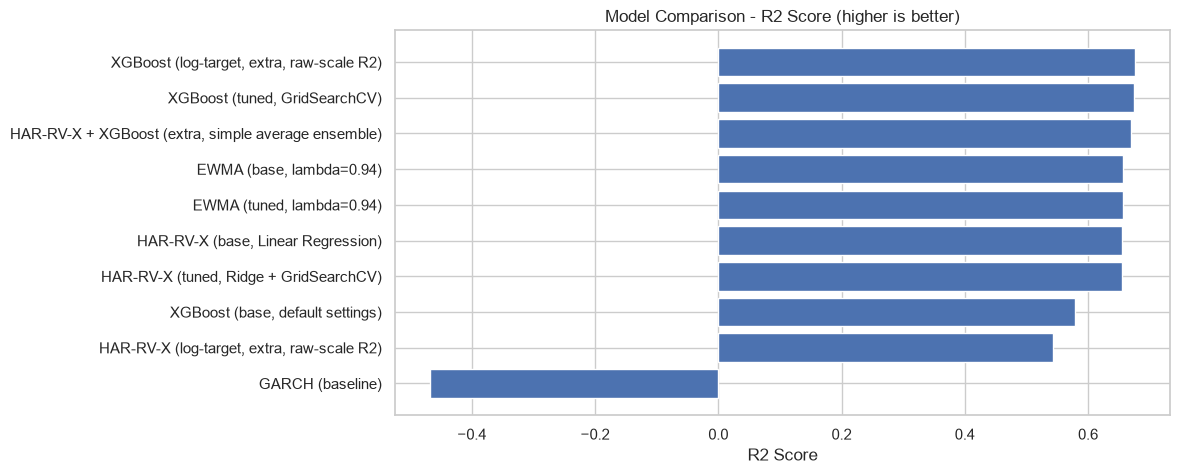

In [229]:
plt.figure(figsize=(10, 5))
plt.barh(results_table["Model"], results_table["R2"])
plt.xlabel("R2 Score")
plt.title("Model Comparison - R2 Score (higher is better)")
plt.gca().invert_yaxis()
plt.show()

### Discussion

**Business implications:** A working 2-day-ahead volatility forecast can be used by
traders to size positions (smaller positions when volatility is expected to be high),
by exchanges to set margin requirements, and by risk teams to plan for how rough the
market might get.

**Limitations:**
- The model only uses price and volume history - it has no access to news, regulation,
  or other market-moving events.
- Volatility is naturally noisy, so even a good model will not achieve a very high R2.
- The chi-square test showed [fill in: whether hour-of-day mattered or not], so that
  information was / was not useful as a feature.

**Future improvements:**
- Add external data, such as trading sentiment or on-chain blockchain activity.
- Test the model on other cryptocurrencies to see if the same approach generalizes.
- Try additional model types (for example, an LSTM neural network) to see if they can
  beat the current best model.

## References & Appendix
**Data source:** Binance (BTC/USDT), hourly OHLCV data, fetched via the CCXT library,
2017-2026.

**Libraries used:** pandas, numpy, matplotlib, seaborn, scipy, statsmodels, scikit-learn,
xgboost, arch.

**Key methods:**
- GARCH: Bollerslev (1986), the standard model for forecasting return volatility.
- HAR (Heterogeneous Autoregressive) model: Corsi (2009), regression on realized
  volatility measured at multiple time horizons.
- EWMA: RiskMetrics methodology (J.P. Morgan, 1996).
- XGBoost: Chen & Guestrin (2016), gradient-boosted decision trees.